# Getting Started with VISTA

VISTA (*VISualization of relation Topologies of Alternatives*) is a visualization framework for Multi-Criteria Decision Analysis (MCDA). It generates color-coded 2-D maps that show how a chosen MCDA ranking method classifies every point in a criterion space relative to a fixed reference alternative. Each pixel is colored according to the relation returned by the method — **better**, **worse**, **indifferent**, or **incomparable** — giving you an immediate, intuitive picture of the method's behavior across the entire decision space.

## 1. Installation

Install **mcda-vista** from PyPI or by downloading the source code (skip this cell if you already have it):

In [1]:
# pip install mcda-vista

## 2. Your First VISTA Map

Let's generate a VISTA map for the **TOPSIS** method — one of the most popular MCDA ranking algorithms. We use `resolution=51` here for speed; bump it to `101` (or higher) for publication-quality figures.

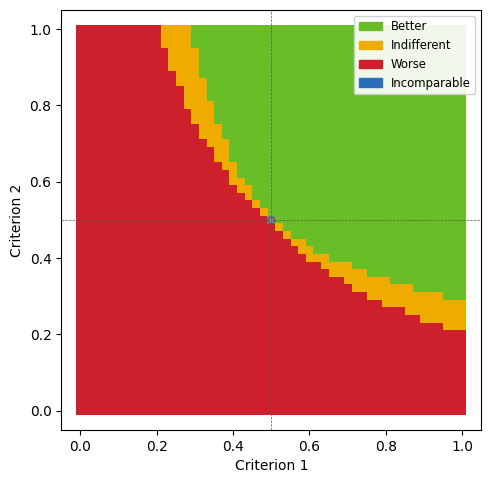

In [2]:
from mcda_vista import generate_vista, plot_vista, Relation, VistaResult

result = generate_vista("topsis", resolution=51, progress=False)
fig = plot_vista(result, point_size=26)

## 3. Understanding the Output

Every point on the map represents a *test alternative* evaluated against the **reference alternative** (shown as a marker). The color tells you the relation returned by the MCDA method:

| Color | Relation | Symbol | Value | Meaning |
|-------|----------|--------|-------|---------|
| 🟩 Green (`#69be28`) | BETTER | P+ | 3 | Test point is preferred over the reference |
| 🟨 Yellow (`#f0ab00`) | INDIFFERENT | I | 2 | Method cannot distinguish the two alternatives |
| 🟥 Red (`#cd202c`) | WORSE | P− | 1 | Reference is preferred over the test point |
| 🟦 Blue (`#2a6ebb`) | INCOMPARABLE | R | 4 | Method cannot order them (partial pre-orders only) |

> **Tip:** Not every method produces all four relations. Ranking-based methods like TOPSIS and SAW typically yield only *better* and *worse*; outranking methods like ELECTRE and PROMETHEE can also produce *indifferent* and *incomparable* regions.

## 4. Exploring the `VistaResult`

The `generate_vista` function returns a `VistaResult` dataclass that bundles everything you need:

In [3]:
print("Method:      ", result.method_name)
print("Resolution:  ", result.resolution)
print("Reference:   ", result.reference)
print("Weights:     ", result.weights)
print("Grid shape:  ", result.grid.shape)
print("Relations:   ", result.relations.shape)
print("Metadata:    ", result.metadata)

Method:       topsis
Resolution:   51
Reference:    [0.5 0.5]
Weights:      [1. 1.]
Grid shape:   (2601, 2)
Relations:    (2601,)
Metadata:     {'elapsed_seconds': 0.3036480999980995}


## 5. The `Relation` Enum

Relations are represented as an `IntEnum` so they are easy to compare and filter:

In [4]:
# List all Relation members with their label and color
for r in Relation:
    print(f"{r.name:15s}  value={r.value}  label={r.label!r:6s}  color={r.color}")

ERROR            value=0  label='Error'  color=#888888
WORSE            value=1  label='Worse'  color=#cd202c
INDIFFERENT      value=2  label='Indifferent'  color=#f0ab00
BETTER           value=3  label='Better'  color=#69be28
INCOMPARABLE     value=4  label='Incomparable'  color=#2a6ebb


In [5]:
# You can also look up a Relation by its symbolic name
print(Relation.from_name("P+"))   # BETTER
print(Relation.from_name("I"))    # INDIFFERENT
print(Relation.from_name("P-"))   # WORSE
print(Relation.from_name("R"))    # INCOMPARABLE

3
2
1
4


## 6. Customizing the Plot

Pass keyword arguments to plot_vista to adjust labels and title:

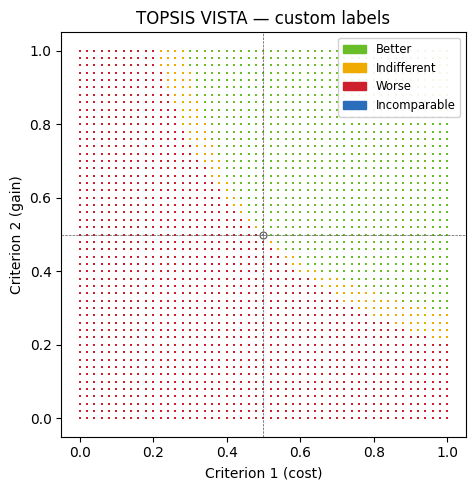

In [6]:
fig = plot_vista(
    result,
    xlabel="Criterion 1 (cost)",
    ylabel="Criterion 2 (gain)",
    title="TOPSIS VISTA \u2014 custom labels",
)

### Controlling point size

By default, plot_vista automatically sizes the scatter markers based
on the resolution (formula: max(0.1, 20 / (resolution / 10))).
You can override this with the point_size parameter.
Larger values produce bolder maps; smaller values reveal finer detail:

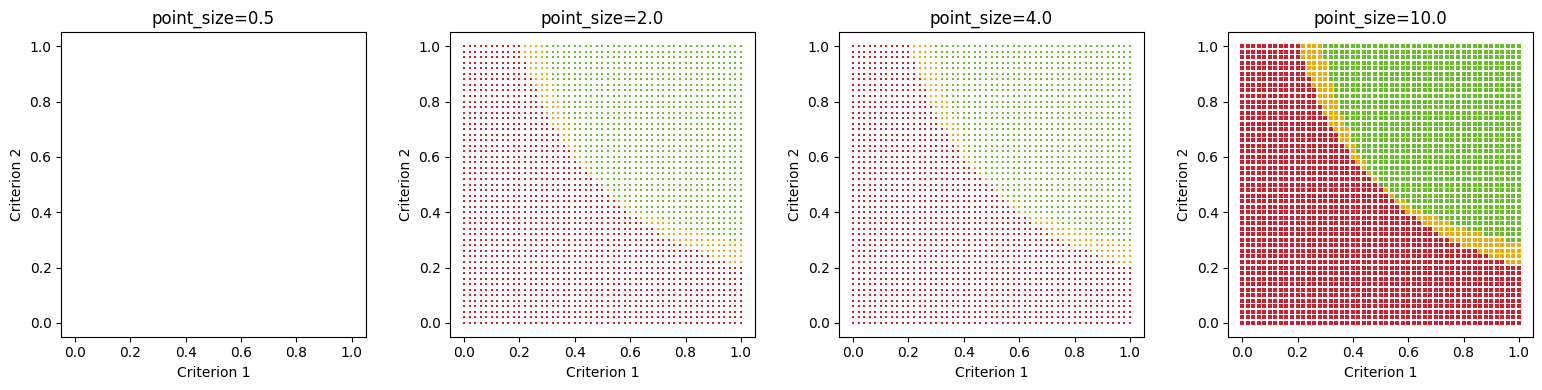

In [7]:
import matplotlib.pyplot as plt

sizes = [0.5, 2.0, 4.0, 10.0]
fig, axes = plt.subplots(1, len(sizes), figsize=(16, 4))

for ax, sz in zip(axes, sizes):
    plot_vista(result, ax=ax, title=f"point_size={sz}", point_size=sz,
              show_legend=False, show_reference=False)

fig.tight_layout()

## 7. Saving the Figure

Use Matplotlib's `savefig` to export the map as a high-resolution image:

Saved to my_first_vista.png


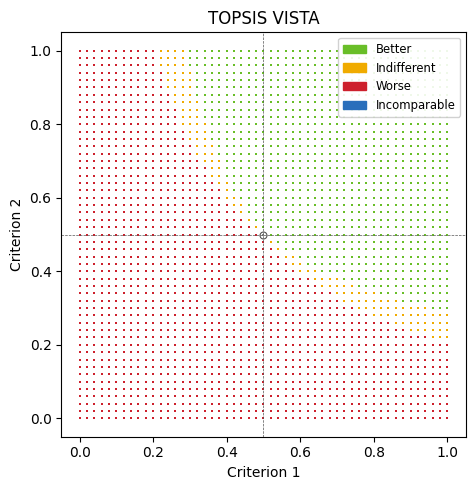

In [8]:
fig = plot_vista(result, title="TOPSIS VISTA")
fig.savefig("my_first_vista.png", dpi=300, bbox_inches="tight")
print("Saved to my_first_vista.png")

## 8. Trying Another Method

Switching methods is as simple as changing the first argument. Here we use **SAW** (*Simple Additive Weighting*) and pass an extra parameter `delta` that controls the indifference threshold:

VISTA (saw): 100%|███████████████████████████████████████████████████████████████| 2601/2601 [00:00<00:00, 7401.81pt/s]


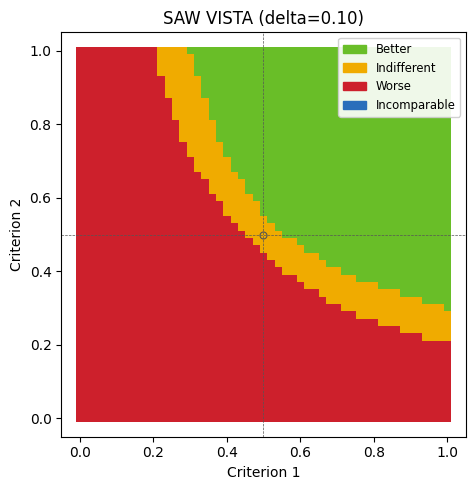

In [9]:
result_saw = generate_vista("saw", resolution=51, delta=0.10)

fig = plot_vista(
    result_saw,
    title="SAW VISTA (delta=0.10)",
    point_size=27
)

Notice how the yellow (indifferent) band appears around the diagonal — the `delta` parameter defines how close two scores must be for the method to consider them indifferent.